In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
from joblib import Parallel, delayed

import pandas as pd
import tqdm

from mf_chromatin_functions import *
from itertools import product

import hictkpy as htk

In [13]:
hic_path = r"GSE63525_IMR90_combined_30.hic"
bin_size = 25_000

f = htk.File(hic_path, bin_size)


In [14]:
f.chromosomes()   # dict: {chrom_name: length_bp}

{'1': 249250621,
 '2': 243199373,
 '3': 198022430,
 '4': 191154276,
 '5': 180915260,
 '6': 171115067,
 '7': 159138663,
 '8': 146364022,
 '9': 141213431,
 '10': 135534747,
 '11': 135006516,
 '12': 133851895,
 '13': 115169878,
 '14': 107349540,
 '15': 102531392,
 '16': 90354753,
 '17': 81195210,
 '18': 78077248,
 '19': 59128983,
 '20': 63025520,
 '21': 48129895,
 '22': 51304566,
 'X': 155270560,
 'Y': 59373566,
 'MT': 16569}

In [15]:
f.resolution()

25000

In [16]:
f.attributes()

{'bin-size': 25000,
 'format': 'HIC',
 'format-version': 7,
 'assembly': 'hg19',
 'format-url': 'https://github.com/aidenlab/hic-format',
 'nbins': 123841,
 'nchroms': 25}

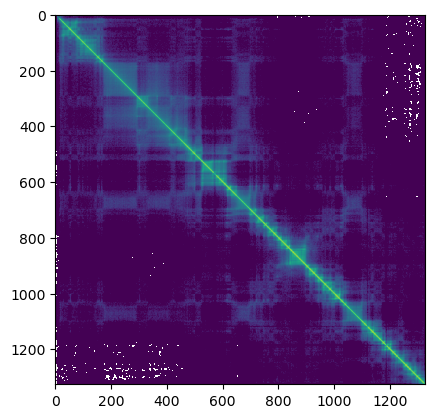

In [17]:
sel = f.fetch("21:15,000,000-48,129,895")
m = sel.to_numpy()
plt.imshow(m, norm=LogNorm())

(80, 80)


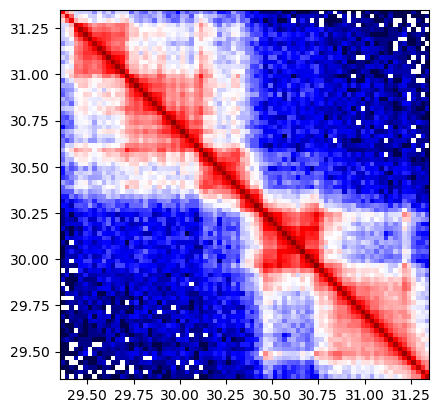

In [22]:
extent = (29.35, 31.35, 29.35, 31.35)
sel = f.fetch("21:29,350,000-31,350,000")
m = sel.to_numpy()
#plt.imshow(np.log10(m), cmap="Reds",)
plt.imshow(m, norm=LogNorm(),cmap="seismic",extent=extent)
print(m.shape)
np.save("chr21_2935_3135.npy", m)

In [19]:

def observed_over_expected(mat, ignore_diags=2, use_nonzero=False):
    """
    mat: (N,N) numpy array, cis contact matrix (preferably balanced, e.g. KR).
    ignore_diags: number of first diagonals to skip (0 = include main diagonal).
    use_nonzero: if True, compute diagonal means using only >0 entries.
    returns: (oe, expected) where expected[d] corresponds to diagonal offset d.
    """
    mat = np.asarray(mat, dtype=float)
    n = mat.shape[0]
    if mat.shape[1] != n:
        raise ValueError("mat must be square")

    expected = np.full(n, np.nan, dtype=float)
    oe = mat.copy()

    for d in range(ignore_diags, n):
        diag = np.diagonal(mat, offset=d)
        if use_nonzero:
            diag = diag[diag > 0]
        # ignore NaNs if present
        mu = np.nanmean(diag) if diag.size else np.nan
        expected[d] = mu

        if not np.isfinite(mu) or mu == 0:
            oe[np.arange(n - d), np.arange(d, n)] = np.nan
            oe[np.arange(d, n), np.arange(n - d)] = np.nan
            continue

        idx = np.arange(n - d)
        oe[idx, idx + d] /= mu
        oe[idx + d, idx] /= mu  # keep symmetry

    # optionally blank ignored diagonals
    for d in range(ignore_diags):
        idx = np.arange(n - d)
        oe[idx, idx + d] = np.nan
        oe[idx + d, idx] = np.nan

    return oe, expected


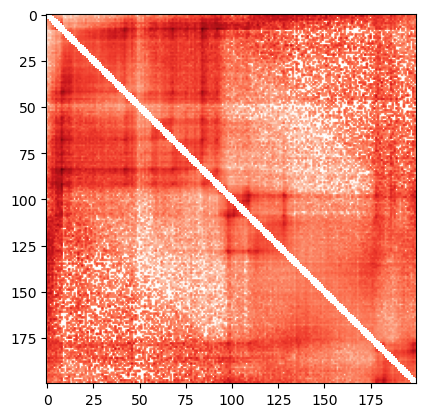

In [20]:
m_norm, _ = observed_over_expected(m)

plt.imshow(m_norm, norm=LogNorm(), cmap="Reds",)